In [20]:
# Creates a multi-model demo notebook and runs it once (using only libraries available in this environment).
# It measures accuracy vs cumulative training time for multiple models and plots them together.
# Models that are not installed are skipped gracefully and reported in the output.

import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbformat as nbf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

In [21]:
# ---------- Helper: safe import ----------
def try_import(module, attr=None):
    try:
        m = __import__(module, fromlist=[attr] if attr else [])
        return (getattr(m, attr) if attr else m), None
    except Exception as e:
        return None, str(e)

# ---------- Build model constructors (graceful if missing) ----------
available_models = {}

# 1) Logistic Regression (baseline, always available via sklearn)
from sklearn.linear_model import LogisticRegression
available_models["LogisticRegression"] = lambda: LogisticRegression(max_iter=1000, n_jobs=1)

# 2) RandomForest
from sklearn.ensemble import RandomForestClassifier
available_models["RandomForest"] = lambda: RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=42)

# 3) SVM (linear SVC for speed and stability)
from sklearn.svm import LinearSVC
available_models["LinearSVM"] = lambda: LinearSVC(max_iter=5000)

# 4) XGBoost
XGBClassifier, err_xgb = try_import("xgboost", "XGBClassifier")
if XGBClassifier is not None:
    available_models["XGBoost"] = lambda: XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", n_jobs=1, random_state=42
    )

# 5) LightGBM
LGBMClassifier, err_lgbm = try_import("lightgbm", "LGBMClassifier")
if LGBMClassifier is not None:
    available_models["LightGBM"] = lambda: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1
    )

# 6) CatBoost
CatBoostClassifier, err_cat = try_import("catboost", "CatBoostClassifier")
if CatBoostClassifier is not None:
    available_models["CatBoost"] = lambda: CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.1, verbose=False, random_state=42
    )

# 7) TabPFN (optional; classifier API)
TabPFNClassifier, err_tabpfn = try_import("tabpfn", "TabPFNClassifier")
if TabPFNClassifier is not None:
    available_models["TabPFN"] = lambda: TabPFNClassifier(device="cpu")

# 8) AutoTabPFN (optional; classifier API can be AutoTabPFNClassifier depending on version)
AutoTabPFNClassifier, err_autotabpfn = try_import("autotabpfn", "AutoTabPFNClassifier")
if AutoTabPFNClassifier is not None:
    available_models["AutoTabPFN"] = lambda: AutoTabPFNClassifier(device="cpu")

# 9) AutoGluon (optional) — handled with special training path
TabularPredictor, err_ag = try_import("autogluon.tabular", "TabularPredictor")
if TabularPredictor is not None:
    # We'll add a placeholder key to handle differently below
    available_models["AutoGluon_(preset)"] = None

skips = {}
for name, ctor in [("XGBoost", XGBClassifier), ("LightGBM", LGBMClassifier), ("CatBoost", CatBoostClassifier),
                   ("TabPFN", TabPFNClassifier), ("AutoTabPFN", AutoTabPFNClassifier), ("AutoGluon", TabularPredictor)]:
    if ctor is None:
        skips[name] = "Not installed: " + (err_xgb if name=="XGBoost" else err_lgbm if name=="LightGBM" else err_cat if name=="CatBoost" else err_tabpfn if name=="TabPFN" else err_autotabpfn if name=="AutoTabPFN" else err_ag)

C:\Users\mebub_9a7jdi8\.conda\envs\tabpfn_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# ---------- Data ----------
X, y = make_classification(
    n_samples=6000, n_features=25, n_informative=12, n_redundant=5, n_classes=2,
    class_sep=1.1, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sample_sizes = np.linspace(300, len(X_train), 10, dtype=int)  # 10 points
repeats = 3  # repeat per size to dampen noise

In [23]:
def benchmark_sklearn_like(model_ctor):
    """Train/evaluate model objects with .fit(X,y) and .predict(X)."""
    per_size_time = []
    per_size_acc = []
    for size in sample_sizes:
        times_k, acc_k = [], []
        for _ in range(repeats):
            clf = model_ctor()
            start = time.time()
            clf.fit(X_train[:size], y_train[:size])
            end = time.time()
            times_k.append(end - start)
            pred = clf.predict(X_test)
            acc_k.append(accuracy_score(y_test, pred))
        per_size_time.append(float(np.median(times_k)))
        per_size_acc.append(float(np.median(acc_k)))
    cum_time = list(np.cumsum(per_size_time))
    return cum_time, per_size_acc

In [24]:
def benchmark_autogluon():
    """Special path for AutoGluon; skip if not installed. Uses quick presets and small time limit per size."""
    if TabularPredictor is None:
        return None, None
    import pandas as pd
    per_size_time, per_size_acc = [], []
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)
    y_train_sr = pd.Series(y_train, name="label")
    y_test_sr = pd.Series(y_test, name="label")
    import tempfile, shutil
    for size in sample_sizes:
        times_k, acc_k = [], []
        for _ in range(repeats):
            train_df = X_train_df.iloc[:size, :].copy()
            train_df["label"] = y_train_sr.iloc[:size].values
            test_df = X_test_df.copy()
            test_df["label"] = y_test_sr.values
            with tempfile.TemporaryDirectory() as tmpdir:
                start = time.time()
                predictor = TabularPredictor(label="label", path=tmpdir, problem_type="binary")
                predictor.fit(train_df, presets="medium_quality_faster_train", time_limit=15, verbosity=0)
                end = time.time()
                times_k.append(end - start)
                pred = predictor.predict(test_df.drop(columns=["label"]))
                acc = (pred.values == test_df["label"].values).mean()
                acc_k.append(acc)
        per_size_time.append(float(np.median(times_k)))
        per_size_acc.append(float(np.median(acc_k)))
    cum_time = list(np.cumsum(per_size_time))
    return cum_time, per_size_acc

In [25]:
# ---------- Run benchmarks ----------
results_rows = []
curves = {}

for name, ctor in available_models.items():
    if name.startswith("AutoGluon"):
        if TabularPredictor is None:
            continue
        cum_time, accs = benchmark_autogluon()
    else:
        cum_time, accs = benchmark_sklearn_like(ctor)

    if cum_time is None:
        continue

    curves[name] = (cum_time, accs)
    for i, size in enumerate(sample_sizes):
        results_rows.append({
            "model": name,
            "sample_size": int(size),
            "cumulative_fit_time_s": float(cum_time[i]),
            "median_accuracy": float(accs[i])
        })

[LightGBM] [Info] Number of positive: 145, number of negative: 155
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2525
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483333 -> initscore=-0.066691
[LightGBM] [Info] Start training from score -0.066691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

C:\Users\mebub_9a7jdi8\.conda\envs\tabpfn_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names


[LightGBM] [Info] Number of positive: 145, number of negative: 155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2525
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483333 -> initscore=-0.066691
[LightGBM] [Info] Start training from score -0.066691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

C:\Users\mebub_9a7jdi8\.conda\envs\tabpfn_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names


[LightGBM] [Info] Number of positive: 145, number of negative: 155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2525
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483333 -> initscore=-0.066691
[LightGBM] [Info] Start training from score -0.066691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

...

C:\Users\mebub_9a7jdi8\.conda\envs\tabpfn_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names


[LightGBM] [Info] Number of positive: 2403, number of negative: 2397
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 4800, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500625 -> initscore=0.002500
[LightGBM] [Info] Start training from score 0.002500


C:\Users\mebub_9a7jdi8\.conda\envs\tabpfn_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names


[LightGBM] [Info] Number of positive: 2403, number of negative: 2397
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6375
[LightGBM] [Info] Number of data points in the train set: 4800, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500625 -> initscore=0.002500
[LightGBM] [Info] Start training from score 0.002500


C:\Users\mebub_9a7jdi8\.conda\envs\tabpfn_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names


In [26]:
# Save results CSV
results_df = pd.DataFrame(results_rows)
csv_path = "accuracy_time_multimodel_results.csv"
results_df.to_csv(csv_path, index=False)

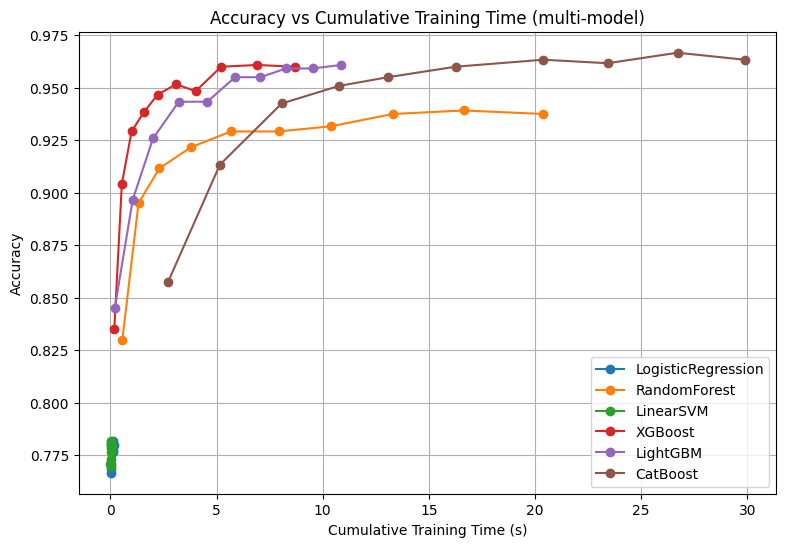

In [27]:
# ---------- Plot ----------
plt.figure(figsize=(9,6))
for name, (cum_time, accs) in curves.items():
    plt.plot(cum_time, accs, marker='o', label=name)
plt.title("Accuracy vs Cumulative Training Time (multi-model)")
plt.xlabel("Cumulative Training Time (s)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
fig_path = "accuracy_time_multimodel_plot.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()